# 06 · Interpretabilidade: SHAP e motivos de recusa

Escolhi o LightGBM como modelo de decisão no [notebook 04](04_lightgbm.ipynb), sabendo que ele não vira uma tabela de pontos como o scorecard. Este notebook resolve essa parte: explicar **por que** o modelo recusa cada proposta.

Isso não é só boa prática. O art. 20 da LGPD dá ao titular o direito de pedir a revisão de decisões tomadas unicamente por tratamento automatizado e de receber informações claras sobre os critérios usados. Na prática, uma cooperativa que recusa crédito com um modelo precisa conseguir dizer ao cooperado quais foram os principais motivos, em linguagem que ele entenda.

O caminho:

1. **visão geral** do modelo com SHAP: quais variáveis pesam mais e em que direção;
2. **explicação individual** de uma proposta recusada;
3. **reason codes**: os 3 principais motivos de cada recusa, gerados automaticamente em português;
4. uma **checagem** contra os motivos do scorecard e uma olhada no efeito da idade.

In [1]:
import warnings

# avisos de mudança de API do shap/tqdm, sem efeito nos resultados
warnings.filterwarnings("ignore", module="shap")
warnings.filterwarnings("ignore", message="IProgress not found")

import json

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import LinearSegmentedColormap

from credit_scoring.data import PROCESSED_DIR, ROOT, TARGET
from credit_scoring.explain import (
    GROUP_LABELS, POINTS_PER_LOGODDS, REASON_GROUPS, group_contributions, lgbm_reason_codes,
    scorecard_reason_codes, shap_values,
)
from credit_scoring.features import FEATURES
import shap
from credit_scoring.plotting import BLUE, GRAY, ORANGE, savefig, set_style
from credit_scoring.reporting import METRICS_PATH, update_metrics
from credit_scoring.scorecard import SCORECARD_FEATURES, proba_to_score

set_style()
pd.set_option("display.max_colwidth", 100)

val = pd.read_parquet(PROCESSED_DIR / "val.parquet")
booster = lgb.Booster(model_file=str(ROOT / "models" / "lightgbm.txt"))
logistic = joblib.load(ROOT / "models" / "logistic_woe.joblib")
cutoff = json.loads(METRICS_PATH.read_text())["cutoff"]["optimal_cutoff"]

p_val = booster.predict(val[FEATURES])
refused = val[p_val > cutoff]
print(f"cutoff {cutoff} → {len(refused):,} de {len(val):,} propostas recusadas na validação ({len(refused) / len(val):.1%})")

cutoff 0.24 → 1,661 de 22,500 propostas recusadas na validação (7.4%)


## 1. Como o SHAP funciona aqui

Para cada proposta, o SHAP divide a previsão do modelo entre as variáveis: parte do risco vem da idade, parte do uso do rotativo, e assim por diante. A soma das contribuições mais um valor base (o risco médio) dá exatamente a previsão. O `TreeExplainer` calcula isso de forma exata para modelos de árvore.

As contribuições saem em log-odds de default. Para ficar na mesma linguagem do scorecard, converto para **pontos de score**: na escala que usei (PDO de 20), cada unidade de log-odds vale cerca de 29 pontos. Então uma contribuição positiva de SHAP (mais risco) significa pontos a menos no score.

In [2]:
contrib, base_value = shap_values(booster, val[FEATURES])
raw = booster.predict(val[FEATURES], raw_score=True)
print(f"erro máximo da soma SHAP + base vs previsão: {np.abs(contrib.sum(axis=1) + base_value - raw).max():.1e}")
print(f"1 unidade de log-odds = {POINTS_PER_LOGODDS:.1f} pontos de score")

erro máximo da soma SHAP + base vs previsão: 1.2e-14
1 unidade de log-odds = 28.9 pontos de score


A soma confere até a 14ª casa decimal. A explicação é exata, não uma aproximação.

## 2. Visão geral do modelo

Cada ponto do gráfico abaixo é um cliente da validação. A posição horizontal mostra quanto aquela variável aumentou (direita) ou reduziu (esquerda) o risco daquele cliente, e a cor mostra se o valor da variável era alto (laranja) ou baixo (azul).

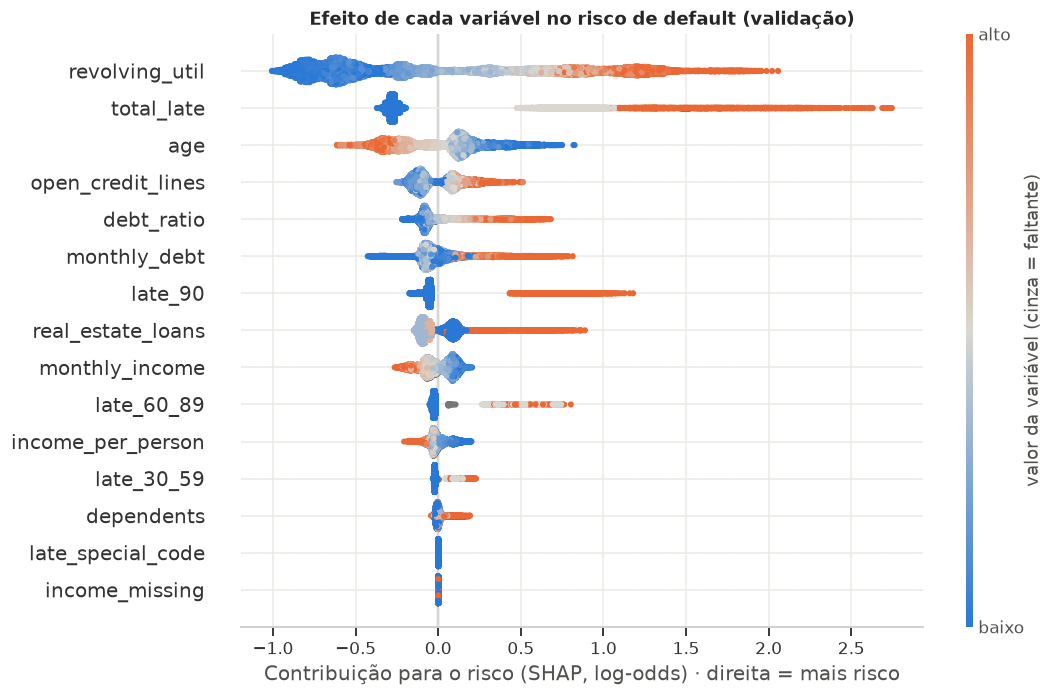

In [3]:
cmap = LinearSegmentedColormap.from_list("blue_orange", [BLUE, "#d9d7d0", ORANGE])
explanation = shap.Explanation(contrib.values, base_values=np.full(len(contrib), base_value),
                               data=val[FEATURES].values, feature_names=FEATURES)
plt.figure()
shap.plots.beeswarm(explanation, max_display=15, color=cmap, show=False, plot_size=(10, 7))
fig = plt.gcf()
fig.axes[0].set_xlabel("Contribuição para o risco (SHAP, log-odds) · direita = mais risco")
fig.axes[0].set_title("Efeito de cada variável no risco de default (validação)", fontweight="bold")
colorbar = fig.axes[1]
colorbar.set_yticklabels(["baixo", "alto"])
colorbar.set_ylabel("valor da variável (cinza = faltante)")
savefig(fig, "shap_beeswarm")
plt.show()

O gráfico confirma o que o EDA e o IV já mostravam, agora pela ótica do modelo:

- **Uso do rotativo** e **total de atrasos** são as variáveis que mais movem o risco. Valores altos (laranja) empurram para a direita, com efeitos fortes.
- **Idade:** os mais jovens (azul) ficam à direita, com mais risco, e os mais velhos à esquerda.
- **Linhas de crédito abertas:** poucas linhas (azul) aumentam o risco, como no U que vimos no EDA.
- As flags `income_missing` e `late_special_code` não têm efeito, pelo motivo visto no notebook 04: o modelo usa os `NaN` diretamente.

Como várias variáveis descrevem o mesmo aspecto do cliente (quatro tratam de atrasos, quatro de renda), para explicar as decisões eu as agrupo em seis **temas**. É isso que vira motivo de recusa: dizer ao cliente "total de atrasos" e "atrasos de 90 dias" como dois motivos separados seria repetir a mesma coisa.

In [4]:
pd.DataFrame({"tema": pd.Series(REASON_GROUPS).map(GROUP_LABELS)}).groupby("tema").apply(
    lambda g: ", ".join(g.index), include_groups=False
).rename("variáveis").to_frame()

,variáveis
tema,
Comprometimento com dívidas,"debt_ratio, monthly_debt"
Histórico de atrasos,"late_30_59, late_60_89, late_90, total_late, late_special_code"
Idade,age
Linhas de crédito e financiamentos,"open_credit_lines, real_estate_loans"
Renda,"monthly_income, income_per_person, income_missing, dependents"
Uso do crédito rotativo,revolving_util


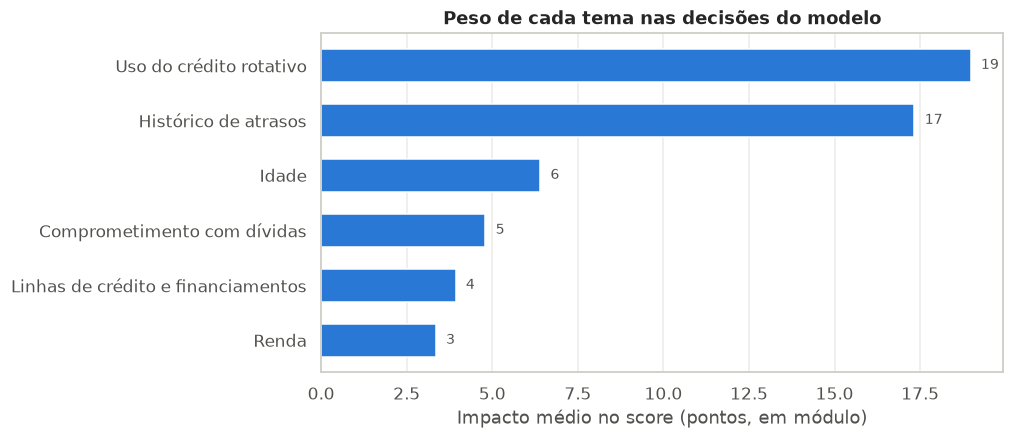

In [5]:
grouped_points = group_contributions(contrib) * POINTS_PER_LOGODDS
mean_abs = grouped_points.abs().mean().rename(index=GROUP_LABELS).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(mean_abs.index, mean_abs.values, color=BLUE, height=0.6)
for i, v in enumerate(mean_abs.values):
    ax.text(v + 0.3, i, f"{v:.0f}", va="center", fontsize=9, color=GRAY)
ax.set_xlabel("Impacto médio no score (pontos, em módulo)")
ax.set_title("Peso de cada tema nas decisões do modelo")
ax.grid(axis="y", visible=False)
savefig(fig, "shap_groups")
plt.show()

## 3. As restrições de negócio aparecem nas explicações?

No notebook 04 obriguei o modelo a respeitar algumas direções, como "mais atraso nunca reduz o risco" e "mais idade nunca aumenta o risco". O gráfico de dependência mostra a contribuição de uma variável contra o seu valor, e é um bom lugar para ver se isso vale na prática. Coloquei ao lado o `revolving_util`, que ficou livre.

Um detalhe: com interações, clientes com o mesmo valor podem ter contribuições um pouco diferentes (a mesma idade pesa diferente dependendo do resto do perfil). O que a restrição garante é que, para um mesmo cliente, aumentar a variável nunca move o risco na direção proibida.

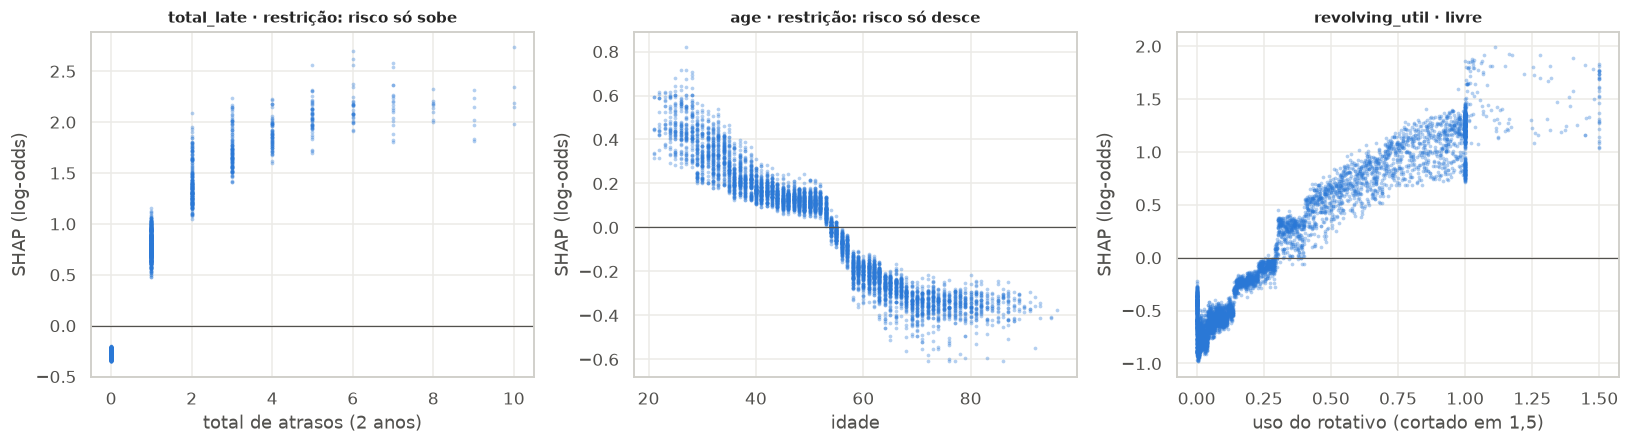

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sample = val.sample(6000, random_state=0).index
for ax, (col, xlabel) in zip(axes, [("total_late", "total de atrasos (2 anos)"), ("age", "idade"),
                                    ("revolving_util", "uso do rotativo (cortado em 1,5)")]):
    x = val.loc[sample, col]
    if col == "revolving_util":
        x = x.clip(upper=1.5)
    ax.scatter(x, contrib.loc[sample, col], s=6, alpha=0.35, color=BLUE, lw=0)
    ax.axhline(0, color=GRAY, lw=0.8)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("SHAP (log-odds)")
axes[0].set_title("total_late · restrição: risco só sobe", fontsize=10)
axes[1].set_title("age · restrição: risco só desce", fontsize=10)
axes[2].set_title("revolving_util · livre", fontsize=10)
axes[0].set_xlim(-0.5, 10.5)
fig.tight_layout()
savefig(fig, "shap_dependence")
plt.show()

O total de atrasos e a idade seguem a direção imposta: cada atraso a mais só aumenta a contribuição para o risco, e cada ano a mais só a reduz.

O `revolving_util`, que ficou livre, preserva o padrão que motivou deixá-lo sem restrição. Quem usa **zero** do limite tem uma contribuição menos favorável do que quem usa só um pouco (a coluna em zero se estende mais para cima). Continua abaixo do risco médio, mas não é o melhor perfil. A partir daí a contribuição sobe de forma contínua, cruza o risco médio por volta de 25–30% de uso e dá um salto quando o saldo passa do limite.

## 4. Uma proposta recusada, explicada

Pego uma proposta recusada em que o motivo principal não é o histórico de atrasos (o caso mais comum, e o mais óbvio), para ver o modelo trabalhando com fatores menos evidentes.

In [7]:
reasons = lgbm_reason_codes(booster, refused)
example_id = reasons[(reasons["motivo_1"] == GROUP_LABELS["uso_rotativo"]) & reasons["motivo_3"].notna()].index[0]

row = val.loc[example_id]
p = p_val[val.index.get_loc(example_id)]
print(f"proposta {example_id}: probabilidade de default {p:.1%} (cutoff {cutoff:.0%}) · score {proba_to_score(p):.0f}")
display(row[FEATURES].to_frame("valor"))

proposta 20982: probabilidade de default 33.5% (cutoff 24%) · score 507


,valor
revolving_util,1.049700
age,42.000000
late_30_59,1.000000
late_60_89,0.000000
late_90,0.000000
debt_ratio,1.531543
monthly_income,1600.000000
open_credit_lines,7.000000
real_estate_loans,2.000000
dependents,0.000000


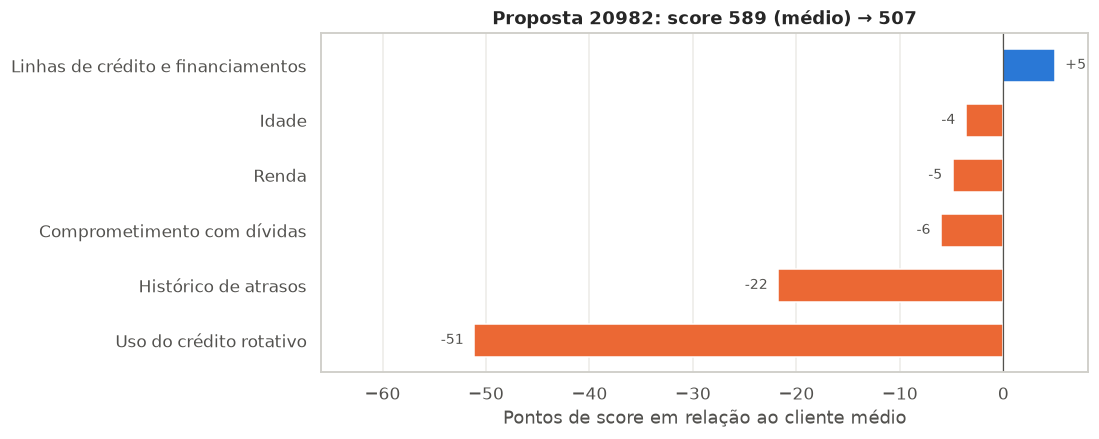

In [8]:
points = (-contrib.loc[example_id] * POINTS_PER_LOGODDS).rename("pontos")
by_theme = (-grouped_points.loc[example_id]).rename(index=GROUP_LABELS).sort_values()
base_score = float(proba_to_score(1 / (1 + np.exp(-base_value))))

fig, ax = plt.subplots(figsize=(9, 4))
colors = [ORANGE if v < 0 else BLUE for v in by_theme.values]
ax.barh(by_theme.index, by_theme.values, color=colors, height=0.6)
for i, v in enumerate(by_theme.values):
    ax.text(v + (1 if v >= 0 else -1), i, f"{v:+.0f}", va="center", ha="left" if v >= 0 else "right", fontsize=9, color=GRAY)
ax.axvline(0, color=GRAY, lw=0.8)
ax.set_xlabel("Pontos de score em relação ao cliente médio")
ax.set_title(f"Proposta {example_id}: score {base_score:.0f} (médio) → {proba_to_score(p):.0f}")
lo, hi = by_theme.min(), by_theme.max()
ax.set_xlim(min(lo, 0) * 1.25 - 2, max(hi, 0) * 1.25 + 2)
ax.grid(axis="y", visible=False)
savefig(fig, "shap_example")
plt.show()

Laranja é o que tirou pontos em relação a um cliente médio, e azul o que somou. A leitura é direta: o saldo do rotativo acima do limite é o principal motivo da recusa, seguido por um atraso recente e por fatores menores. Um tema jogou a favor do cliente (as linhas de crédito e financiamentos). Isso também é informação útil para ele, porque ajuda a entender o que já está bom e o que mudaria a decisão.

## 5. Reason codes: os motivos de cada recusa

Para cada proposta recusada, pego os três temas que mais tiraram pontos e gero uma frase em português com o dado do próprio cliente. Um fator que **ajudou** o cliente nunca aparece como motivo de recusa. Por isso algumas propostas têm menos de três motivos.

In [9]:
reasons.head(6)[["motivo_1", "detalhe_1", "pontos_1", "motivo_2", "detalhe_2", "pontos_2", "motivo_3", "detalhe_3", "pontos_3"]]

,motivo_1,detalhe_1,pontos_1,motivo_2,detalhe_2,pontos_2,motivo_3,detalhe_3,pontos_3
id,,,,,,,,,
20982,Uso do crédito rotativo,Saldo do crédito rotativo acima do limite contratado (105% do limite),51,Histórico de atrasos,Atrasos nos últimos 2 anos: 1 atraso de 30 a 59 dias,22,Comprometimento com dívidas,Comprometimento de 153% da renda mensal com dívidas,6
76275,Histórico de atrasos,"Atrasos nos últimos 2 anos: 1 atraso de 90 dias ou mais, 2 atrasos de 60 a 89 dias, 4 atrasos de...",97,Uso do crédito rotativo,Uso de 100% do limite do crédito rotativo,23,Renda,Renda mensal de R$ 3.558 para 3 pessoas,4
30299,Histórico de atrasos,"Atrasos nos últimos 2 anos: 2 atrasos de 90 dias ou mais, 1 atraso de 60 a 89 dias, 1 atraso de ...",90,Uso do crédito rotativo,Uso de 100% do limite do crédito rotativo,22,Renda,Renda mensal de R$ 1.817 para 1 pessoa,4
64268,Histórico de atrasos,"Atrasos nos últimos 2 anos: 2 atrasos de 90 dias ou mais, 2 atrasos de 60 a 89 dias, 2 atrasos d...",88,Uso do crédito rotativo,Saldo do crédito rotativo acima do limite contratado (112% do limite),33,Comprometimento com dívidas,Comprometimento de 82% da renda mensal com dívidas,14
141256,Histórico de atrasos,Atrasos nos últimos 2 anos: 2 atrasos de 90 dias ou mais,61,Uso do crédito rotativo,Uso de 100% do limite do crédito rotativo,23,Idade,Faixa etária (32 anos) com maior risco histórico na carteira,6
55819,Histórico de atrasos,"Atrasos nos últimos 2 anos: 1 atraso de 90 dias ou mais, 1 atraso de 60 a 89 dias, 2 atrasos de ...",75,Uso do crédito rotativo,Saldo do crédito rotativo acima do limite contratado (106% do limite),35,Renda,Renda mensal de R$ 3.490 para 2 pessoas,3


Na prática, isso vira o texto que o cooperado recebe. Por exemplo, para a proposta analisada acima:

In [10]:
def refusal_letter(r: pd.Series) -> str:
    lines = ["Sua proposta de crédito não foi aprovada nesta análise. Os principais fatores considerados foram:", ""]
    for i in range(1, 4):
        if pd.notna(r.get(f"motivo_{i}")):
            lines.append(f"  {i}. {r[f'motivo_{i}']}: {r[f'detalhe_{i}']}")
    lines += ["", "Você pode solicitar a revisão desta decisão por um analista (LGPD, art. 20)."]
    return "\n".join(lines)

print(refusal_letter(reasons.loc[example_id]))

Sua proposta de crédito não foi aprovada nesta análise. Os principais fatores considerados foram:

  1. Uso do crédito rotativo: Saldo do crédito rotativo acima do limite contratado (105% do limite)
  2. Histórico de atrasos: Atrasos nos últimos 2 anos: 1 atraso de 30 a 59 dias
  3. Comprometimento com dívidas: Comprometimento de 153% da renda mensal com dívidas

Você pode solicitar a revisão desta decisão por um analista (LGPD, art. 20).


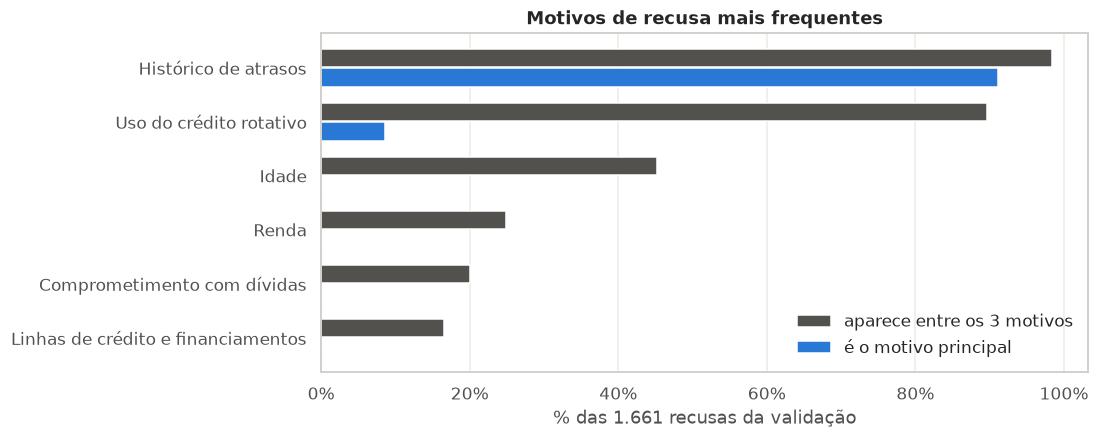

In [11]:
top1 = reasons["motivo_1"].value_counts(normalize=True)
in_top3 = pd.concat([reasons[f"motivo_{i}"] for i in range(1, 4)]).value_counts() / len(reasons)
summary = pd.DataFrame({"motivo principal": top1, "entre os 3 motivos": in_top3}).fillna(0).sort_values("entre os 3 motivos")

fig, ax = plt.subplots(figsize=(9, 4))
y = np.arange(len(summary))
ax.barh(y + 0.18, summary["entre os 3 motivos"], height=0.34, color=GRAY, label="aparece entre os 3 motivos")
ax.barh(y - 0.18, summary["motivo principal"], height=0.34, color=BLUE, label="é o motivo principal")
ax.set_yticks(y)
ax.set_yticklabels(summary.index)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_xlabel(f"% das {len(reasons):,} recusas da validação".replace(",", "."))
ax.set_title("Motivos de recusa mais frequentes")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
savefig(fig, "reason_codes_frequency")
plt.show()

O histórico de atrasos é o motivo principal na grande maioria das recusas, e o uso do rotativo aparece como principal ou complementar em quase todas. Faz sentido: são as duas variáveis mais fortes do modelo, e o cutoff ótimo recusa só a faixa de risco mais alto, onde esses dois sinais se concentram.

## 6. Checagem: os motivos batem com os do scorecard?

O scorecard tem um método clássico e exato para gerar motivos: em cada variável, quantos pontos o cliente deixou de ganhar em relação à melhor faixa. Se os dois modelos contam histórias muito diferentes para o mesmo cliente, isso seria um sinal de alerta.

In [12]:
reasons_sc = scorecard_reason_codes(logistic, refused)
sc_top3 = reasons_sc[["motivo_1", "motivo_2", "motivo_3"]].values
agree_top1 = (reasons["motivo_1"] == reasons_sc["motivo_1"]).mean()
lgbm_top1_in_sc_top3 = np.mean([m in set(s) for m, s in zip(reasons["motivo_1"], sc_top3)])
print(f"mesmo motivo principal: {agree_top1:.0%}")
print(f"motivo principal do LightGBM está entre os 3 do scorecard: {lgbm_top1_in_sc_top3:.1%}")
pd.crosstab(reasons["motivo_1"], reasons_sc["motivo_1"], rownames=["LightGBM (SHAP)"], colnames=["scorecard"])

mesmo motivo principal: 68%
motivo principal do LightGBM está entre os 3 do scorecard: 99.9%


scorecard,Histórico de atrasos,Uso do crédito rotativo
LightGBM (SHAP),,
Comprometimento com dívidas,0,3
Histórico de atrasos,981,532
Linhas de crédito e financiamentos,0,2
Uso do crédito rotativo,0,143


Os dois modelos concordam no essencial: o motivo principal do LightGBM praticamente sempre está entre os três motivos do scorecard. A discordância no motivo principal vem quase toda de uma troca entre atrasos e uso do rotativo, e tem uma explicação metodológica, não de modelo.

Os dois métodos medem "perda" em relação a referências diferentes. O SHAP compara com o **cliente médio**, e o scorecard compara com a **melhor faixa possível**. A diferença entre a melhor faixa de uso do rotativo e o limite estourado é grande no scorecard. Mas como o cliente médio já usa uma parte do limite, pelo SHAP o rotativo "perde" menos pontos e os atrasos passam na frente.

Nenhuma das duas referências está errada, mas é uma escolha que precisa ser documentada e mantida estável. Aqui fico com o SHAP, porque é o método do modelo que de fato toma a decisão.

## 7. Um ponto de atenção: a idade

A idade aparece entre os três motivos em quase metade das recusas. Idade não é dado sensível pela definição da LGPD, mas a lei tem o princípio da não discriminação (art. 6º, IX), e recusar crédito por idade é um tema delicado. Vale ao menos medir o efeito:

In [13]:
approved = p_val <= cutoff
age_band = pd.cut(val["age"], [17, 30, 40, 50, 60, 70, 120], labels=["até 30", "31–40", "41–50", "51–60", "61–70", "70+"])
age_table = pd.DataFrame({"n": age_band.value_counts().sort_index(),
                          "taxa_default_real": val.groupby(age_band, observed=True)[TARGET].mean(),
                          "aprovação": pd.Series(approved, index=val.index).groupby(age_band, observed=True).mean()})
age_in_reasons = (pd.concat([reasons[f"motivo_{i}"] for i in range(1, 4)]) == GROUP_LABELS["idade"]).groupby(level=0).any().mean()
print(f"a idade aparece entre os 3 motivos em {age_in_reasons:.0%} das recusas")
age_table.style.format({"taxa_default_real": "{:.1%}", "aprovação": "{:.1%}", "n": "{:,}"})

a idade aparece entre os 3 motivos em 45% das recusas


,n,taxa_default_real,aprovação
age,,,
até 30,"1,665",10.6%,84.9%
31–40,"3,518",10.0%,88.0%
41–50,"5,187",8.6%,91.0%
51–60,"5,297",6.1%,93.1%
61–70,"4,197",3.4%,97.2%
70+,"2,636",2.4%,98.7%


A aprovação cresce com a idade, acompanhando a taxa de default real de cada faixa, que é bem maior entre os mais jovens. O modelo está refletindo um padrão que existe nos dados, e não inventando um. Mesmo assim, o tema não se resolve só com estatística. Numa instituição real, eu levaria três perguntas para a área de compliance:

1. Manter a idade como variável, sabendo que o ganho é moderado? (No IV ela era a sexta variável.)
2. Se mantiver, a idade deve aparecer como motivo de recusa para o cliente, ou a comunicação deve focar nos fatores que ele consegue mudar?
3. Vale monitorar a aprovação por faixa etária em produção, para garantir que ela não se distancie do risco real?

Não mudo o modelo aqui, porque essa decisão não é técnica. Mas o fato de o problema ter aparecido é justamente o valor de ter explicações.

## 8. Salvando

In [14]:
reasons.to_csv(ROOT / "reports" / "reason_codes_val.csv")
update_metrics("explainability", {
    "set": "val",
    "n_refused": int(len(reasons)),
    "top1_reason_share": {k: round(float(v), 4) for k, v in top1.items()},
    "top1_agreement_with_scorecard": round(float(agree_top1), 4),
    "lgbm_top1_in_scorecard_top3": round(float(lgbm_top1_in_sc_top3), 4),
    "age_in_reasons_share": round(float(age_in_reasons), 4),
})["explainability"]

{'set': 'val',
 'n_refused': 1661,
 'top1_reason_share': {'Histórico de atrasos': 0.9109,
  'Uso do crédito rotativo': 0.0861,
  'Comprometimento com dívidas': 0.0018,
  'Linhas de crédito e financiamentos': 0.0012},
 'top1_agreement_with_scorecard': 0.6767,
 'lgbm_top1_in_scorecard_top3': 0.9988,
 'age_in_reasons_share': 0.4521}